# LSTM

## Import libraries

In [234]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from lightning.pytorch.callbacks import EarlyStopping


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import TRAINED_MODELS_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

## Parameters

In [235]:
TARGET_COLUMN = "close"
TARGET_COLUMN

'close'

In [236]:
FROM_DATE = "2000-01-01"
TO_DATE = "2025-06-30"

In [237]:
INPUT_SIZE = 40
OUTPUT_SIZE = 10
NUMBER_OF_TRAIN_WINDOW = 3000
NUMBER_OF_VALIDATION_WINDOW = 200
NUMBER_OF_TEST_WINDOW = 200

## Hyper Parameters

In [238]:
MAX_EPOCHS = 100
LEARNING_RATE = 0.001
PATIENCE = 30

## Start

### Get data

In [239]:
my_logger = Logger(file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/lstm/test")

In [240]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [241]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [242]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [243]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = vn_index_df.astype(dtype_map)

In [244]:
vn_index_df

,date,open,high,low,close,volume
0,2000-01-03,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9308,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9309,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9310,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9311,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [245]:
vn_index_transform_df = (
    vn_index_df.copy().dropna(subset=["close"]).reset_index(drop=True)
)

In [246]:
vn_index_transform_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [247]:
vn_index_transform_sub_df = (
    vn_index_transform_df[
        (vn_index_transform_df["date"] >= FROM_DATE)
        & (vn_index_transform_df["date"] <= TO_DATE)
    ]
    .copy()
    .reset_index(drop=True)
)

In [248]:
vn_index_transform_sub_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


### Create plot

In [249]:
my_visualizer = Visualizer(logger=my_logger)

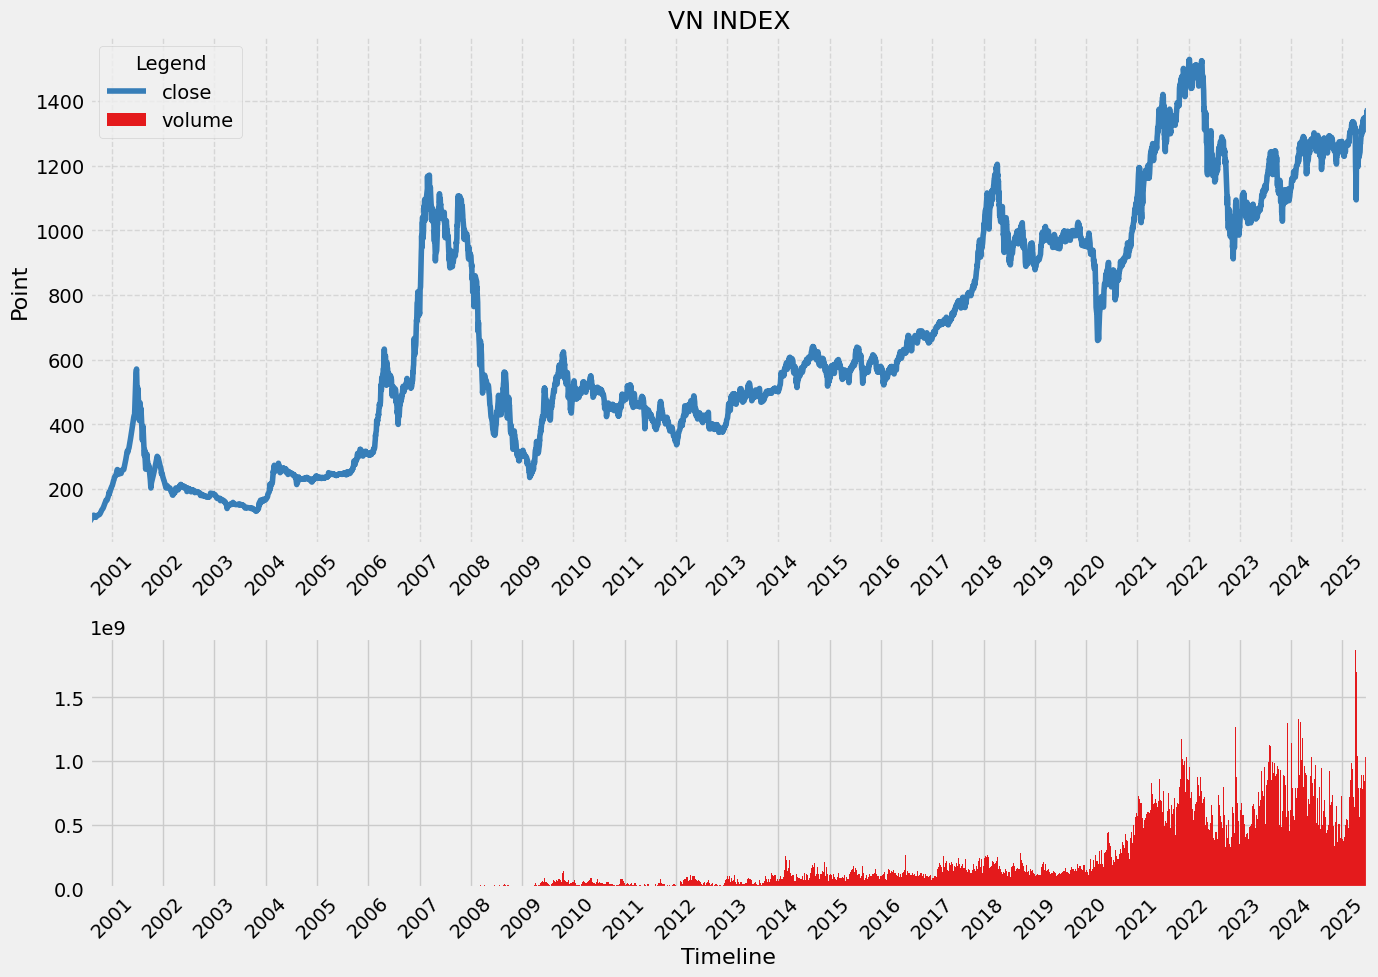

In [250]:
vn_index_plot = my_visualizer.plot_lines_bars_chart(
    vn_index_transform_sub_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN INDEX",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    suffix_figure_name=f"{FROM_DATE}_{TO_DATE}",
    marker=None,
    min_date_offset=pd.DateOffset(days=2),
    max_date_offset=pd.DateOffset(days=2),
)
vn_index_plot

### Create train validation test 

In [251]:
data = vn_index_transform_sub_df[["close"]].copy()

### Move the target column to the last column

In [252]:
cols = [col for col in data.columns if col != "close"] + ["close"]
data = data[cols]

In [253]:
data

,close
0,106.920000
1,107.780000
2,108.640000
3,109.500000
4,110.360000
...,...
9099,1481.626667
9100,1309.380000
9101,1068.436667
9102,1068.256667


In [255]:
data.shape

(9104, 1)

In [256]:
train_set_range = (0, INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW + OUTPUT_SIZE)
validation_set_range = (
    train_set_range[1],
    train_set_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_VALIDATION_WINDOW,
)
test_set_range = (
    validation_set_range[1],
    validation_set_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_TEST_WINDOW,
)
print(train_set_range, validation_set_range, test_set_range)

(0, 3050) (3050, 3300) (3300, 3550)


In [257]:
train_set = np.array(data[train_set_range[0] : train_set_range[1]])
validation_set = np.array(data[validation_set_range[0] : validation_set_range[1]])
test_set = np.array(data[test_set_range[0] : test_set_range[1]])

In [258]:
train_set[:5, :]

array([[106.92],
       [107.78],
       [108.64],
       [109.5 ],
       [110.36]])

In [259]:
train_set.shape

(3050, 1)

In [260]:
validation_set[:5, :]

array([[475.2],
       [463.8],
       [458.1],
       [438.6],
       [456.2]])

In [261]:
validation_set.shape

(250, 1)

In [262]:
test_set[:5, :]

array([[531.76666667],
       [531.9       ],
       [516.1       ],
       [510.9       ],
       [519.7       ]])

In [263]:
len(test_set)

250

In [264]:
# Create feature_scaler
feature_scaler = MinMaxScaler()

# Fit scaler ONLY on train data
feature_train_scaler = feature_scaler.fit_transform(train_set)

feature_validation_scaled = feature_scaler.transform(validation_set)

# Transform test data using same feature_scaler
feature_test_scaled = feature_scaler.transform(test_set)

print("Train scaled shape:", feature_train_scaler.shape)
print("Validation scaled shape:", feature_validation_scaled.shape)
print("Test scaled shape:", feature_test_scaled.shape)

Train scaled shape: (3050, 1)
Validation scaled shape: (250, 1)
Test scaled shape: (250, 1)


In [265]:
feature_scaler.data_min_, feature_scaler.data_max_

(array([106.34666667]), array([1170.67]))

In [266]:
# Create target_scaler
target_scaler = MinMaxScaler()

# Fit scaler ONLY on train data
target_train_scaler = target_scaler.fit_transform(train_set[:, -1].reshape(-1, 1))

target_validation_scaled = target_scaler.transform(validation_set[:, -1].reshape(-1, 1))

# Transform test data using same featuretarget_scaler_scaler
target_test_scaled = target_scaler.transform(test_set[:, -1].reshape(-1, 1))

print("Train scaled shape:", target_train_scaler.shape)
print("Validation scaled shape:", target_validation_scaled.shape)
print("Test scaled shape:", target_test_scaled.shape)

Train scaled shape: (3050, 1)
Validation scaled shape: (250, 1)
Test scaled shape: (250, 1)


In [267]:
target_scaler.data_min_, target_scaler.data_max_

(array([106.34666667]), array([1170.67]))

In [268]:
train_inputs = []
train_outputs = []

for i in range(NUMBER_OF_TRAIN_WINDOW + 1):
    train_input = feature_train_scaler[i : i + INPUT_SIZE]
    train_inputs.append(train_input)
    train_output = feature_train_scaler[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE][
        :, -1
    ]
    train_outputs.append(train_output)

train_inputs = torch.tensor(np.array(train_inputs), dtype=torch.float32)
train_outputs = torch.tensor(np.array(train_outputs), dtype=torch.float32)

In [269]:
train_inputs[0]

tensor([[0.0005],
        [0.0013],
        [0.0022],
        [0.0030],
        [0.0038],
        [0.0048],
        [0.0054],
        [0.0062],
        [0.0070],
        [0.0078],
        [0.0086],
        [0.0092],
        [0.0097],
        [0.0102],
        [0.0110],
        [0.0119],
        [0.0118],
        [0.0117],
        [0.0112],
        [0.0106],
        [0.0100],
        [0.0091],
        [0.0083],
        [0.0074],
        [0.0066],
        [0.0063],
        [0.0061],
        [0.0060],
        [0.0058],
        [0.0057],
        [0.0057],
        [0.0062],
        [0.0068],
        [0.0073],
        [0.0082],
        [0.0091],
        [0.0101],
        [0.0110],
        [0.0110],
        [0.0111]])

In [270]:
train_inputs.shape

torch.Size([3001, 40, 1])

In [271]:
train_outputs[0]

tensor([0.0111, 0.0111, 0.0111, 0.0114, 0.0117, 0.0118, 0.0119, 0.0122, 0.0125,
        0.0130])

In [272]:
train_outputs.shape

torch.Size([3001, 10])

In [273]:
validation_inputs = []
validation_outputs = []

for i in range(NUMBER_OF_VALIDATION_WINDOW + 1):
    validation_input = feature_validation_scaled[i : i + INPUT_SIZE]
    validation_inputs.append(validation_input)
    validation_output = feature_validation_scaled[
        i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE
    ][:, -1]
    validation_outputs.append(validation_output)

validation_inputs = torch.tensor(np.array(validation_inputs), dtype=torch.float32)
validation_outputs = torch.tensor(np.array(validation_outputs), dtype=torch.float32)

In [274]:
validation_inputs[0]

tensor([[0.3466],
        [0.3359],
        [0.3305],
        [0.3122],
        [0.3287],
        [0.3265],
        [0.3336],
        [0.3333],
        [0.3330],
        [0.3327],
        [0.3213],
        [0.3041],
        [0.3077],
        [0.3092],
        [0.3151],
        [0.3210],
        [0.3269],
        [0.3206],
        [0.3199],
        [0.3195],
        [0.3124],
        [0.3048],
        [0.3010],
        [0.2934],
        [0.3014],
        [0.3074],
        [0.3029],
        [0.2979],
        [0.2930],
        [0.2880],
        [0.2913],
        [0.2942],
        [0.3080],
        [0.3273],
        [0.3320],
        [0.3367],
        [0.3414],
        [0.3351],
        [0.3304],
        [0.3247]])

In [275]:
validation_inputs.shape

torch.Size([201, 40, 1])

In [276]:
validation_outputs[0]

tensor([0.3387, 0.3394, 0.3397, 0.3479, 0.3523, 0.3524, 0.3517, 0.3550, 0.3583,
        0.3616])

In [277]:
validation_outputs.shape

torch.Size([201, 10])

In [278]:
test_inputs = []
test_outputs = []

for i in range(NUMBER_OF_TEST_WINDOW + 1):
    test_input = feature_test_scaled[i : i + INPUT_SIZE]
    test_inputs.append(test_input)
    test_output = feature_test_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE][
        :, -1
    ]
    test_outputs.append(test_output)

test_inputs = torch.tensor(np.array(test_inputs), dtype=torch.float32)
test_outputs = torch.tensor(np.array(test_outputs), dtype=torch.float32)

In [279]:
test_inputs[0]

tensor([[0.3997],
        [0.3998],
        [0.3850],
        [0.3801],
        [0.3884],
        [0.3849],
        [0.3835],
        [0.3173],
        [0.3821],
        [0.3808],
        [0.3760],
        [0.3812],
        [0.3731],
        [0.3748],
        [0.3750],
        [0.3751],
        [0.3752],
        [0.3705],
        [0.3691],
        [0.3776],
        [0.3797],
        [0.3824],
        [0.3838],
        [0.3842],
        [0.3847],
        [0.3848],
        [0.3862],
        [0.3870],
        [0.3878],
        [0.3886],
        [0.3645],
        [0.3901],
        [0.3905],
        [0.3872],
        [0.3856],
        [0.3841],
        [0.3884],
        [0.3974],
        [0.3978],
        [0.3983]])

In [280]:
test_inputs.shape

torch.Size([201, 40, 1])

In [281]:
test_outputs[0]

tensor([0.3987, 0.3992, 0.4034, 0.4067, 0.4097, 0.4110, 0.4122, 0.4135, 0.4147,
        0.4160])

In [282]:
test_outputs.shape

torch.Size([201, 10])

### Create dataloader

In [283]:
train_dataset = TensorDataset(train_inputs, train_outputs)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [284]:
validation_dataset = TensorDataset(validation_inputs, validation_outputs)
validation_dataloader = DataLoader(validation_dataset, batch_size=32)

In [285]:
test_dataset = TensorDataset(test_inputs, test_outputs)
test_dataloader = DataLoader(test_dataset, batch_size=32)

### Create model

In [ ]:
class LightningLSTM(L.LightningModule):

    def __init__(self):

        super().__init__()

        L.seed_everything(seed=18)

        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)

        self.fc = nn.Linear(64, OUTPUT_SIZE)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)

        # Lấy hidden state cuối
        last_hidden = h_n[-1]

        out = self.fc(last_hidden)

        return out

    def configure_optimizers(
        self,
    ):  # this configures the optimizer we want to use for backpropagation.
        return Adam(
            self.parameters(), lr=LEARNING_RATE
        )  ## we'll just go ahead and set the learning rate to 0.1

    def training_step(self, batch):  # take a step during gradient descent.
        input_i, label_i = batch  # collect input
        output_i = self(input_i)  # run input through the neural network
        loss = F.mse_loss(output_i, label_i)

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch):  # take a step during validation.
        input_i, label_i = batch  # collect input
        output_i = self(input_i)  # run input through the neural network
        loss = F.mse_loss(output_i, label_i, prog_bar=True)

        self.log("val_loss", loss)

        return loss

In [291]:
model = LightningLSTM()

print("Before optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

Seed set to 18


Before optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-1.0484e-03],
        [-1.0311e-02],
        [-2.5984e-02],
        [ 6.3031e-02],
        [ 1.0549e-01],
        [ 2.6122e-02],
        [ 1.2774e-02],
        [ 1.1020e-02],
        [-8.2084e-02],
        [-7.0766e-02],
        [-1.1628e-01],
        [ 1.1143e-01],
        [ 5.5068e-03],
        [-5.3945e-02],
        [ 1.0031e-01],
        [ 5.0035e-02],
        [ 7.0979e-02],
        [ 1.3157e-03],
        [-6.3421e-02],
        [ 3.1799e-02],
        [ 6.1024e-02],
        [ 6.9101e-02],
        [ 1.0299e-01],
        [-1.2352e-01],
        [-9.8242e-03],
        [-8.8347e-02],
        [-4.3345e-02],
        [ 9.6206e-02],
        [ 1.7600e-02],
        [ 5.0061e-02],
        [-7.0681e-02],
        [-9.7671e-02],
        [ 9.1092e-02],
        [-1.1202e-01],
        [ 1.9068e-02],
        [-5.7930e-02],
        [ 8.7599e-02],
        [-1.2487e-02],
        [-6.4902e-02],
        [-1.0158e-01],
        [-9.7040e-0

In [292]:
print("Before training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0])}")

Before training
Observed: tensor([0.0111, 0.0111, 0.0111, 0.0114, 0.0117, 0.0118, 0.0119, 0.0122, 0.0125,
        0.0130])
Predicted: tensor([-0.1015, -0.1053,  0.0948,  0.0693, -0.1024,  0.0124,  0.0133,  0.1384,
         0.1030, -0.0858], grad_fn=<ViewBackward0>)


### Train model

In [293]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [294]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

print("After optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm │ LSTM   │ 17.2 K │ train │     0 │
│ 1 │ fc   │ Linear │    650 │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 17.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 17.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

After optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-1.3822e-01],
        [-2.4327e-02],
        [ 6.7757e-02],
        [ 3.6541e-01],
        [ 2.5959e-01],
        [ 1.4495e-01],
        [ 1.8291e-02],
        [ 2.1138e-01],
        [-1.3736e-02],
        [-4.6020e-02],
        [-1.1555e-01],
        [-2.7518e-02],
        [ 1.1016e-01],
        [ 7.5571e-02],
        [ 2.6321e-01],
        [-6.1914e-02],
        [-8.5575e-02],
        [-6.9969e-03],
        [ 5.1366e-02],
        [ 1.1518e-01],
        [ 2.2327e-01],
        [ 2.0688e-01],
        [ 2.3912e-01],
        [-1.6869e-02],
        [-6.2074e-02],
        [-3.0722e-02],
        [-1.7351e-01],
        [-4.4872e-02],
        [ 1.1938e-01],
        [ 2.1058e-01],
        [ 5.0097e-02],
        [-8.5697e-03],
        [ 2.2619e-01],
        [-2.0152e-02],
        [-3.9979e-02],
        [ 7.6287e-02],
        [ 2.4273e-01],
        [-2.4327e-01],
        [ 7.5068e-02],
        [-1.2057e-01],
        [ 4.2580e-02

In [295]:
print("After training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0])}")

After training
Observed: tensor([0.0111, 0.0111, 0.0111, 0.0114, 0.0117, 0.0118, 0.0119, 0.0122, 0.0125,
        0.0130])
Predicted: tensor([0.0095, 0.0072, 0.0100, 0.0106, 0.0113, 0.0130, 0.0101, 0.0125, 0.0133,
        0.0139], grad_fn=<ViewBackward0>)


In [296]:
print("After training")
print(f"Observed: {validation_outputs[0]}")
print(f"Predicted: {model(validation_inputs[0])}")

After training
Observed: tensor([0.3387, 0.3394, 0.3397, 0.3479, 0.3523, 0.3524, 0.3517, 0.3550, 0.3583,
        0.3616])
Predicted: tensor([0.3241, 0.3206, 0.3256, 0.3236, 0.3276, 0.3259, 0.3236, 0.3278, 0.3283,
        0.3288], grad_fn=<ViewBackward0>)


In [297]:
print("After training")
print(f"Observed: {test_outputs[0]}")
print(f"Predicted: {model(test_inputs[0])}")

After training
Observed: tensor([0.3987, 0.3992, 0.4034, 0.4067, 0.4097, 0.4110, 0.4122, 0.4135, 0.4147,
        0.4160])
Predicted: tensor([0.3901, 0.3852, 0.3903, 0.3879, 0.3916, 0.3897, 0.3875, 0.3925, 0.3925,
        0.3941], grad_fn=<ViewBackward0>)


In [298]:
test_outputs

tensor([[0.3987, 0.3992, 0.4034,  ..., 0.4135, 0.4147, 0.4160],
        [0.3992, 0.4034, 0.4067,  ..., 0.4147, 0.4160, 0.4150],
        [0.4034, 0.4067, 0.4097,  ..., 0.4160, 0.4150, 0.4164],
        ...,
        [0.3534, 0.3048, 0.3083,  ..., 0.3244, 0.3228, 0.3298],
        [0.3048, 0.3083, 0.3134,  ..., 0.3228, 0.3298, 0.3364],
        [0.3083, 0.3134, 0.3134,  ..., 0.3298, 0.3364, 0.3368]])

### Plot test data

In [299]:
import numpy as np


def stitch_sequences(seq_list):
    stitched = []

    for i, seq in enumerate(seq_list):

        # Tensor → numpy
        if hasattr(seq, "detach"):
            seq = seq.detach().cpu().numpy()

        seq = np.array(seq).flatten()

        if i == 0:
            stitched.extend(seq)  # full first window
        else:
            stitched.append(seq[-1])  # only last value

    return np.array(stitched)

In [300]:
pred_list = [model(inp) for inp in test_inputs]

observed_full = data[test_set_range[0] + INPUT_SIZE : test_set_range[1]][TARGET_COLUMN]
predicted_full = target_scaler.inverse_transform(
    stitch_sequences(pred_list).reshape(-1, 1)
)

In [301]:
len(observed_full)

210

In [302]:
len(predicted_full)

210

In [303]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_continuous(observed, predicted, figsize=(12, 5), linewidth=3):

    x = range(len(observed))

    plt.figure(figsize=figsize)

    plt.plot(x, observed, label="Observed", linewidth=linewidth)
    plt.plot(x, predicted, label="Predicted", linewidth=linewidth)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend()
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title(f"VN INDEX - Input size: {INPUT_SIZE} - Output size: {OUTPUT_SIZE}")
    plt.savefig(f"VN INDEX - Input size {INPUT_SIZE} Output size {OUTPUT_SIZE}.png")
    plt.tight_layout()
    plt.show()

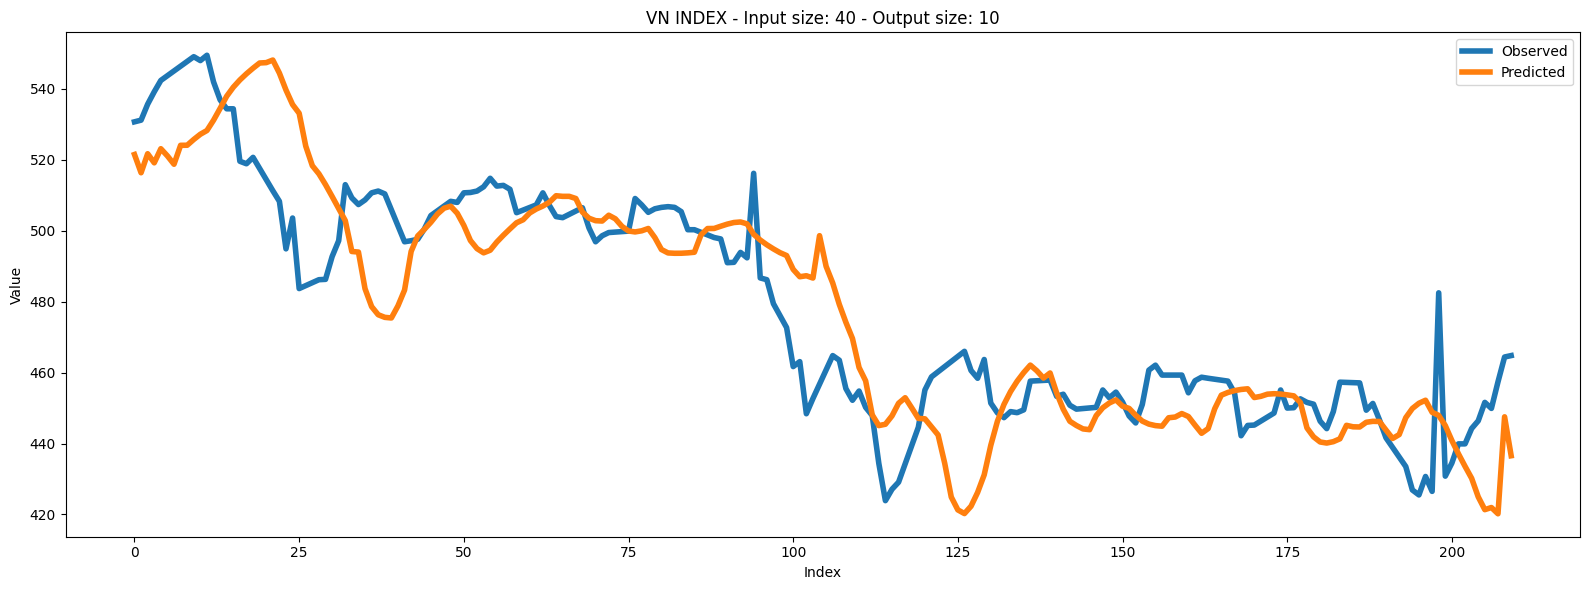

In [309]:
plot_continuous(observed_full, predicted_full, figsize=(16, 6), linewidth=4)

In [305]:
# for slot in range(NUMBER_OF_TEST_WINDOW // OUTPUT_SIZE):
#     plot_continuous(
#         data[
#             test_set_range[0]
#             + INPUT_SIZE
#             + OUTPUT_SIZE * slot : test_set_range[0]
#             + INPUT_SIZE
#             + OUTPUT_SIZE * (slot + 1)
#         ],
#         predicted_full[OUTPUT_SIZE * slot : OUTPUT_SIZE * (slot + 1)],
#         figsize=(16, 6),
#         linewidth=4,
#     )

### Calculate R^2

In [316]:
import numpy as np


def r2_score(observed, predicted):
    observed = np.array(observed).reshape(-1, 1)
    predicted = np.array(predicted).reshape(-1, 1)

    ss_res = np.sum((observed - predicted) ** 2)  # Residual sum of squares
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)  # Total sum of squares

    return 1 - (ss_res / ss_tot)

In [317]:
print(r2_score(observed_full, predicted_full))

0.6941046333982437


In [308]:
# tensorboard --logdir=src/model/lightning_logs/